In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nih_chest_xrays_data_path = kagglehub.dataset_download('nih-chest-xrays/data')
biditdas06_nih_chestxray14_path = kagglehub.dataset_download('biditdas06/nih-chestxray14')

print('Data source import complete.')


In [ ]:
# ============================================================
# SECTION 1 : IMPORTS & CONFIGURATION
# ============================================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Torchvision
import torchvision
from torchvision import transforms, models

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    multilabel_confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Train/Test Split
from sklearn.model_selection import train_test_split

# Mixed Precision
from torch.cuda.amp import GradScaler, autocast

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# ============================================================
# SECTION 2 : GLOBAL CONFIGURATION
# ============================================================

# Dataset Paths
DATASET_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

CSV_PATH = os.path.join(DATASET_ROOT, "Data_Entry_2017.csv")

TRAIN_LIST = os.path.join(DATASET_ROOT, "train_val_list.txt")

TEST_LIST = os.path.join(DATASET_ROOT, "test_list.txt")

# Image folders
IMAGE_FOLDERS = [
    os.path.join(DATASET_ROOT, f"images_{i:03d}", "images")
    for i in range(1, 13)
]

# Image Parameters
IMAGE_SIZE = 320

BATCH_SIZE = 16

NUM_CLASSES = 14

NUM_WORKERS = 2

# Training
EPOCHS = 20

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

# Early Stopping
PATIENCE = 5

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("Device :", DEVICE)
print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)
print("Epochs :", EPOCHS)
print("="*60)

Device : cuda
Image Size : 320
Batch Size : 16
Epochs : 20


In [ ]:
# ============================================================
# SECTION 3 : LOAD DATASET
# ============================================================

import pandas as pd
import os

# Read CSV
df = pd.read_csv(CSV_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("Shape :", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Loaded Successfully
Shape : (112120, 12)

Columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
# ============================================================
# SECTION 4 : KEEP ONLY 8 DISEASES
# ============================================================

TARGET_DISEASES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumothorax"
]

print("Number of Diseases :", len(TARGET_DISEASES))
print(TARGET_DISEASES)

Number of Diseases : 8
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumothorax']


In [ ]:
# Create one-hot columns

for disease in TARGET_DISEASES:
    df[disease] = df["Finding Labels"].str.contains(disease).astype(int)

df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Atelectasis,Cardiomegaly,Consolidation,Effusion,Infiltration,Mass,Nodule,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,0,1,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,0,1,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,0,1,0,1,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,0,0,0,0,0,0,0,0


In [ ]:
# Keep only images containing at least one selected disease

df = df[df[TARGET_DISEASES].sum(axis=1) > 0]

df = df.reset_index(drop=True)

print("Remaining Images :", len(df))

Remaining Images : 47683


In [ ]:
# Disease Distribution

disease_counts = df[TARGET_DISEASES].sum().sort_values(ascending=False)

print(disease_counts)

Infiltration     19894
Effusion         13317
Atelectasis      11559
Nodule            6331
Mass              5782
Pneumothorax      5302
Consolidation     4667
Cardiomegaly      2776
dtype: int64


In [ ]:
# ============================================================
# SECTION 5 : BUILD IMAGE PATHS
# ============================================================

image_dict = {}

for folder in IMAGE_FOLDERS:

    for image_name in os.listdir(folder):

        image_dict[image_name] = os.path.join(folder, image_name)

df["Image_Path"] = df["Image Index"].map(image_dict)

missing = df["Image_Path"].isna().sum()

print("Missing Images :", missing)

Missing Images : 0


In [ ]:
# ============================================================
# SECTION 6 : PATIENT-WISE SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

patients = df["Patient ID"].unique()

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.20,
    random_state=42
)

train_patients, valid_patients = train_test_split(
    train_patients,
    test_size=0.10,
    random_state=42
)

train_df = df[df["Patient ID"].isin(train_patients)].reset_index(drop=True)

valid_df = df[df["Patient ID"].isin(valid_patients)].reset_index(drop=True)

test_df = df[df["Patient ID"].isin(test_patients)].reset_index(drop=True)

print("="*50)

print("Train :", train_df.shape)

print("Validation :", valid_df.shape)

print("Test :", test_df.shape)

Train : (34565, 21)
Validation : (3779, 21)
Test : (9339, 21)


In [ ]:
# Verify No Patient Leakage

common_train_valid = set(train_df["Patient ID"]).intersection(
    set(valid_df["Patient ID"])
)

common_train_test = set(train_df["Patient ID"]).intersection(
    set(test_df["Patient ID"])
)

common_valid_test = set(valid_df["Patient ID"]).intersection(
    set(test_df["Patient ID"])
)

print("Train ↔ Validation :", len(common_train_valid))
print("Train ↔ Test :", len(common_train_test))
print("Validation ↔ Test :", len(common_valid_test))

Train ↔ Validation : 0
Train ↔ Test : 0
Validation ↔ Test : 0


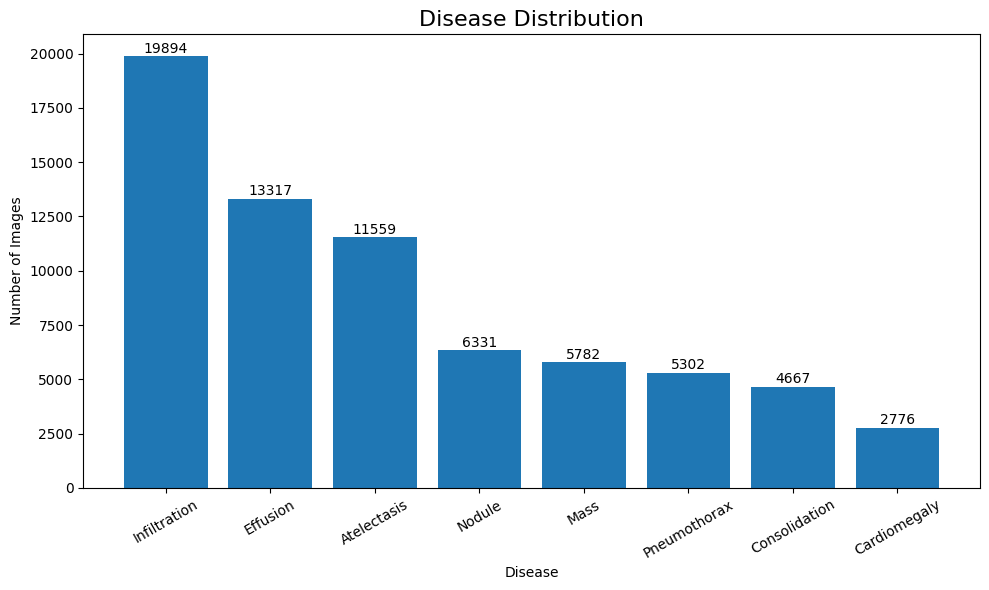

In [ ]:
# ============================================================
# SECTION 7.1 : DISEASE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

disease_counts = df[TARGET_DISEASES].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(
    disease_counts.index,
    disease_counts.values
)

plt.title("Disease Distribution", fontsize=16)
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 150,
        f"{int(height)}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

1    31070
2    12341
3     3411
4      696
5      134
6       28
7        3
Name: count, dtype: int64


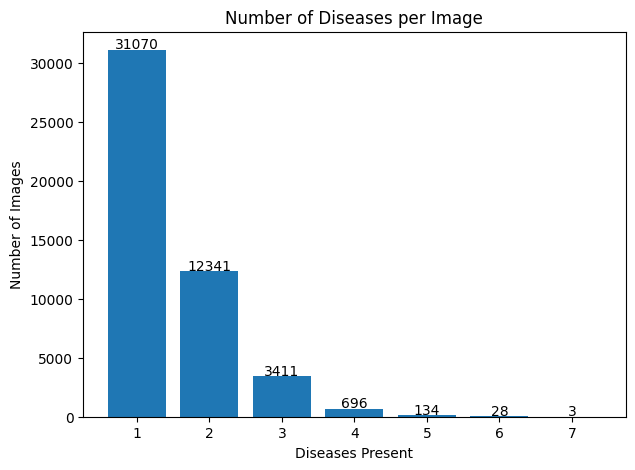

In [ ]:
# ============================================================
# SECTION 7.2 : MULTI-LABEL DISTRIBUTION
# ============================================================

label_count = df[TARGET_DISEASES].sum(axis=1)

distribution = label_count.value_counts().sort_index()

print(distribution)

plt.figure(figsize=(7,5))

bars = plt.bar(
    distribution.index.astype(str),
    distribution.values
)

plt.title("Number of Diseases per Image")
plt.xlabel("Diseases Present")
plt.ylabel("Number of Images")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+100,
        int(bar.get_height()),
        ha="center"
    )

plt.show()

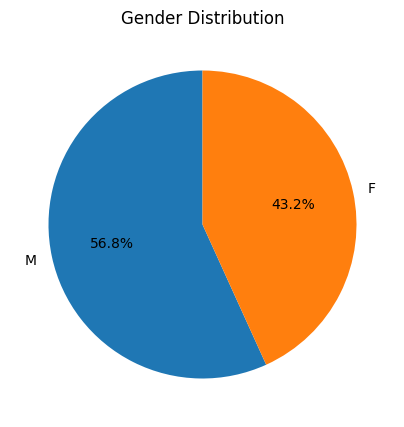

In [ ]:
# ============================================================
# SECTION 7.3 : GENDER DISTRIBUTION
# ============================================================

gender = df["Patient Gender"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

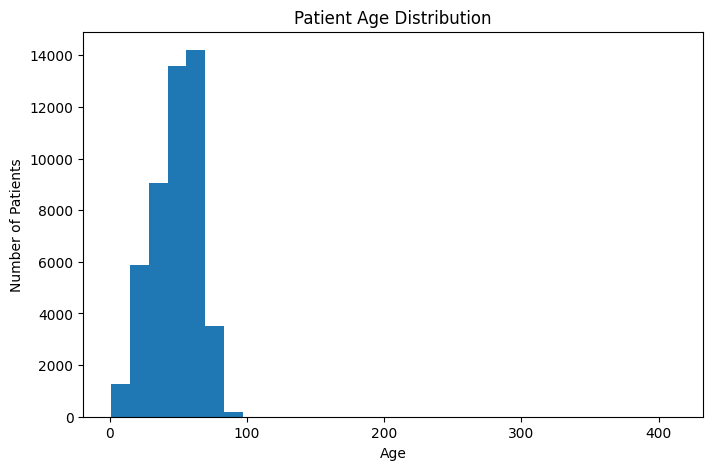

In [ ]:
# ============================================================
# SECTION 7.4 : AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    df["Patient Age"],
    bins=30
)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

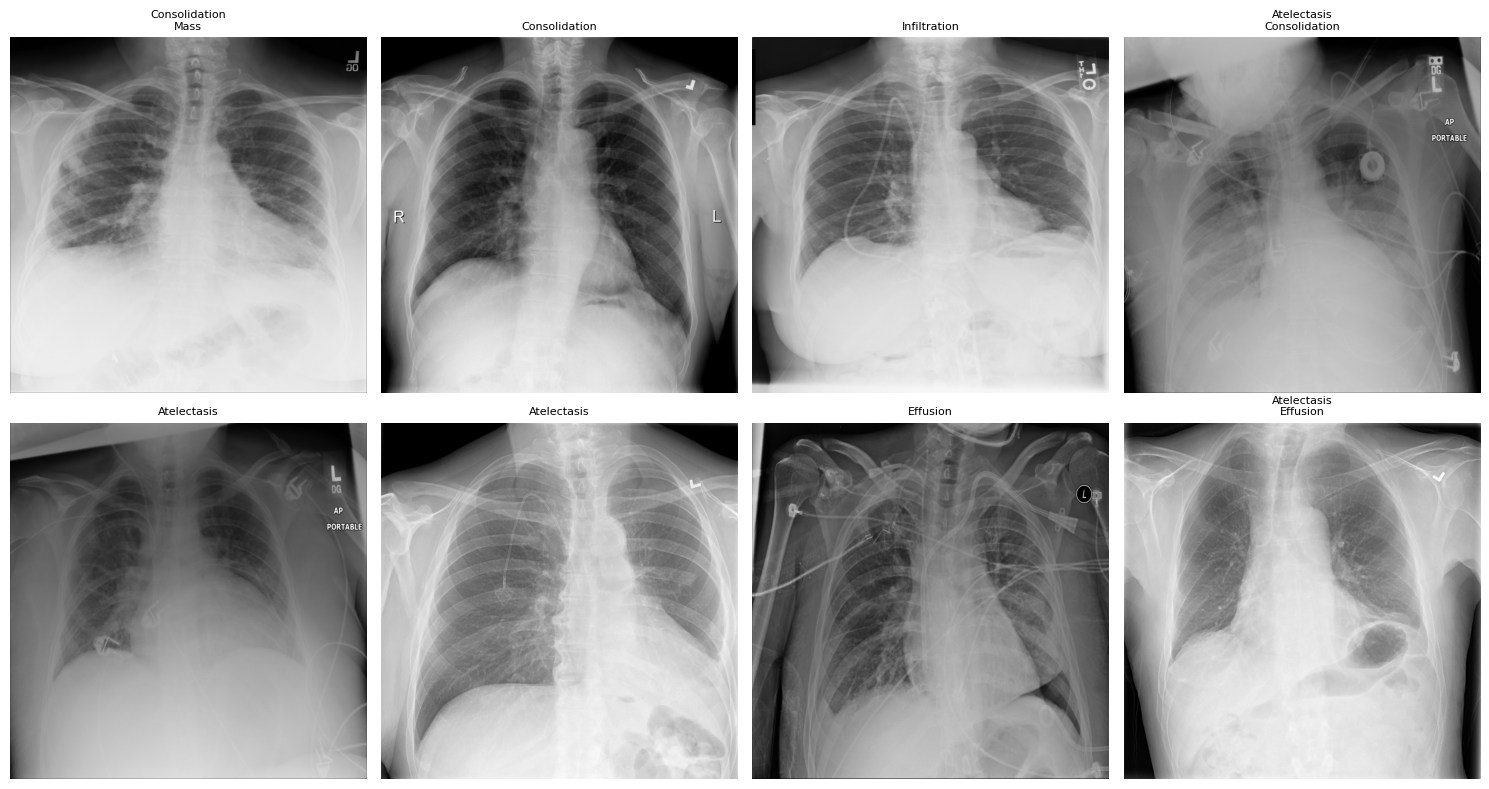

In [ ]:
# ============================================================
# SECTION 7.5 : SAMPLE X-RAYS
# ============================================================

import random
from PIL import Image

samples = df.sample(8, random_state=42)

fig, axes = plt.subplots(2,4, figsize=(15,8))

axes = axes.flatten()

for ax, (_, row) in zip(axes, samples.iterrows()):

    img = Image.open(row["Image_Path"]).convert("L")

    ax.imshow(img, cmap="gray")

    labels = []

    for disease in TARGET_DISEASES:
        if row[disease] == 1:
            labels.append(disease)

    ax.set_title("\n".join(labels), fontsize=8)

    ax.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
!pip install -q albumentations

In [ ]:
import albumentations as A

print(A.__version__)

2.0.8


In [ ]:
# ============================================================
# SECTION 8.1 : DATA AUGMENTATION
# ============================================================

import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 320

train_transform = A.Compose([

    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.HorizontalFlip(p=0.5),

    A.Rotate(
        limit=7,
        border_mode=0,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),

    A.CLAHE(
        clip_limit=2,
        p=0.3
    ),

    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()

])

valid_transform = A.Compose([

    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()

])

print("Transforms Created Successfully")

Transforms Created Successfully


In [ ]:
# ============================================================
# SECTION 9 : CUSTOM DATASET
# ============================================================

from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image = Image.open(row["Image_Path"]).convert("RGB")

        image = np.array(image)

        label = row[TARGET_DISEASES].values.astype(np.float32)

        if self.transform:

            image = self.transform(image=image)["image"]

        return image, torch.tensor(label)

In [ ]:
# ============================================================
# SECTION 10 : DATASET OBJECTS
# ============================================================

train_dataset = ChestXrayDataset(
    train_df,
    transform=train_transform
)

valid_dataset = ChestXrayDataset(
    valid_df,
    transform=valid_transform
)

test_dataset = ChestXrayDataset(
    test_df,
    transform=valid_transform
)

print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

34565
3779
9339


In [ ]:
# ============================================================
# SECTION 11 : DATALOADER
# ============================================================

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(valid_loader))
print("Test Batches :", len(test_loader))

Train Batches : 2161
Validation Batches : 237
Test Batches : 584


In [ ]:
images, labels = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Label Shape :", labels.shape)

print(labels[0])

Image Shape : torch.Size([16, 3, 320, 320])
Label Shape : torch.Size([16, 8])
tensor([0., 0., 0., 1., 0., 0., 0., 0.])


In [ ]:
# ============================================================
# DEVICE CONFIGURATION
# ============================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : Tesla T4


In [ ]:
!pip install -q timm

In [ ]:
import timm
import torch
import torch.nn as nn

print("timm Version :", timm.__version__)

timm Version : 1.0.26


In [ ]:
# ============================================================
# SECTION 13 : MODEL
# ============================================================

NUM_CLASSES = len(TARGET_DISEASES)

model = timm.create_model(
    "densenet121",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): DenseBlock(
      (denselayer1): DenseLayer(
        (norm1): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
  

In [ ]:
# Freeze all parameters

for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier

for param in model.classifier.parameters():
    param.requires_grad = True

print("Backbone Frozen")
print("Classifier Trainable")

Backbone Frozen
Classifier Trainable


In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters : {trainable:,}")

print(f"Total Parameters : {total:,}")

Trainable Parameters : 8,200
Total Parameters : 6,962,056


In [ ]:
# ============================================================
# SECTION 14 : POSITIVE CLASS WEIGHTS
# ============================================================

import numpy as np

counts = train_df[TARGET_DISEASES].sum().values

negatives = len(train_df) - counts

pos_weight = negatives / counts

pos_weight = torch.tensor(
    pos_weight,
    dtype=torch.float32
).to(device)

print(pos_weight)

tensor([ 3.1173, 16.6442,  9.0949,  2.5689,  1.3992,  7.3531,  6.6370,  8.0650],
       device='cuda:0')


In [ ]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-6
)

In [ ]:
scaler = torch.amp.GradScaler("cuda")

In [ ]:
best_loss = float("inf")

patience = 5

counter = 0

In [ ]:
print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): DenseBlock(
      (denselayer1): DenseLayer(
        (norm1): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
  

In [ ]:
print(pos_weight)

tensor([ 3.1173, 16.6442,  9.0949,  2.5689,  1.3992,  7.3531,  6.6370,  8.0650],
       device='cuda:0')


In [ ]:
print(trainable)
print(total)

8200
6962056


In [ ]:
# ============================================================
# TRAINING IMPORTS
# ============================================================

import numpy as np
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import torch

In [ ]:
# ============================================================
# HISTORY
# ============================================================

history = {

    "train_loss": [],
    "valid_loss": [],

    "train_accuracy": [],
    "valid_accuracy": [],

    "train_precision": [],
    "valid_precision": [],

    "train_recall": [],
    "valid_recall": [],

    "train_f1": [],
    "valid_f1": [],

    "train_auc": [],
    "valid_auc": []

}

In [ ]:
def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion,
                    scaler,
                    device):

    model.train()

    running_loss = 0

    all_labels = []
    all_probs = []

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)

        all_probs.append(probs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    preds = (all_probs > 0.5).astype(int)

    accuracy = accuracy_score(
        all_labels.flatten(),
        preds.flatten()
    )

    precision = precision_score(
        all_labels,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        preds,
        average="macro",
        zero_division=0
    )

    auc = roc_auc_score(
        all_labels,
        all_probs,
        average="macro"
    )

    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1,
        auc
    )

In [ ]:
def validate(model,
             loader,
             criterion,
             device):

    model.eval()

    running_loss = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():

        loop = tqdm(loader)

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    preds = (all_probs > 0.5).astype(int)

    accuracy = accuracy_score(
        all_labels.flatten(),
        preds.flatten()
    )

    precision = precision_score(
        all_labels,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        preds,
        average="macro",
        zero_division=0
    )

    auc = roc_auc_score(
        all_labels,
        all_probs,
        average="macro"
    )

    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1,
        auc
    )

In [ ]:
best_loss = float("inf")

patience = 5

counter = 0

num_epochs = 5

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,      # CHANGE THIS
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,      # CHANGE THIS
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,      # CHANGE THIS
    pin_memory=True
)

In [ ]:
for epoch in range(num_epochs):

    print("="*60)

    print(f"Epoch [{epoch+1}/{num_epochs}]")

    train_loss, train_acc, train_pre, train_rec, train_f1, train_auc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler,
        device
    )

    valid_loss, valid_acc, valid_pre, valid_rec, valid_f1, valid_auc = validate(
        model,
        valid_loader,
        criterion,
        device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    history["train_accuracy"].append(train_acc)
    history["valid_accuracy"].append(valid_acc)

    history["train_precision"].append(train_pre)
    history["valid_precision"].append(valid_pre)

    history["train_recall"].append(train_rec)
    history["valid_recall"].append(valid_rec)

    history["train_f1"].append(train_f1)
    history["valid_f1"].append(valid_f1)

    history["train_auc"].append(train_auc)
    history["valid_auc"].append(valid_auc)

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Valid Loss      : {valid_loss:.4f}")

    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Valid Accuracy  : {valid_acc:.4f}")

    print(f"Train Precision : {train_pre:.4f}")
    print(f"Valid Precision : {valid_pre:.4f}")

    print(f"Train Recall    : {train_rec:.4f}")
    print(f"Valid Recall    : {valid_rec:.4f}")

    print(f"Train F1        : {train_f1:.4f}")
    print(f"Valid F1        : {valid_f1:.4f}")

    print(f"Train ROC-AUC   : {train_auc:.4f}")
    print(f"Valid ROC-AUC   : {valid_auc:.4f}")

    if valid_loss < best_loss:

        best_loss = valid_loss

        counter = 0

        torch.save(model.state_dict(), "best_model.pth")

        print("✅ Best model saved.")

    else:

        counter += 1

        print(f"Early Stopping Counter : {counter}/{patience}")

    if counter >= patience:

        print("\n🛑 Early Stopping Triggered.")

        break

Epoch [1/15]


  0%|          | 0/2161 [00:00<?, ?it/s]

  0%|          | 0/237 [00:00<?, ?it/s]

Train Loss      : 1.0044
Valid Loss      : 1.0234
Train Accuracy  : 0.6733
Valid Accuracy  : 0.6853
Train Precision : 0.2884
Valid Precision : 0.3019
Train Recall    : 0.6418
Valid Recall    : 0.6290
Train F1        : 0.3832
Valid F1        : 0.3941
Train ROC-AUC   : 0.7151
Valid ROC-AUC   : 0.7158
✅ Best model saved.
Epoch [2/15]


  0%|          | 0/2161 [00:00<?, ?it/s]

...

  0%|          | 0/237 [00:00<?, ?it/s]

Train Loss      : 0.8622
Valid Loss      : 0.9920
Train Accuracy  : 0.7382
Valid Accuracy  : 0.7193
Train Precision : 0.3623
Valid Precision : 0.3381
Train Recall    : 0.7055
Valid Recall    : 0.6538
Train F1        : 0.4670
Valid F1        : 0.4343
Train ROC-AUC   : 0.7955
Valid ROC-AUC   : 0.7504
Early Stopping Counter : 4/5
Epoch [10/15]


  0%|          | 0/2161 [00:00<?, ?it/s]

  0%|          | 0/237 [00:00<?, ?it/s]

Train Loss      : 0.8542
Valid Loss      : 1.0156
Train Accuracy  : 0.7431
Valid Accuracy  : 0.7184
Train Precision : 0.3693
Valid Precision : 0.3445
Train Recall    : 0.7122
Valid Recall    : 0.6496
Train F1        : 0.4745
Valid F1        : 0.4397
Train ROC-AUC   : 0.7998
Valid ROC-AUC   : 0.7497
Early Stopping Counter : 5/5

🛑 Early Stopping Triggered.


In [ ]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

print("Model Loaded Successfully ✅")

FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pth'

In [ ]:
# ============================================================
# STAGE 2 : FINE TUNING
# ============================================================

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze DenseBlock4
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

# Unfreeze Final BatchNorm
for param in model.features.norm5.parameters():
    param.requires_grad = True

# Unfreeze Classifier
for param in model.classifier.parameters():
    param.requires_grad = True

print("Stage 2 Ready!")

Stage 2 Ready!


In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

Trainable Parameters : 2,168,328
Total Parameters     : 6,962,056


In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15,
    eta_min=1e-6
)

In [ ]:
best_loss = float("inf")
counter = 0
patience = 5

num_epochs = 15

In [ ]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)

FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pth'

In [ ]:
best_loss = float("inf")
counter = 0
patience = 5
num_epochs = 15

In [ ]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

import torch

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

print("✅ Best Model Loaded")

NameError: name 'model' is not defined

In [ ]:
import numpy as np
from tqdm.auto import tqdm

all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

print(all_probs.shape)
print(all_labels.shape)

  0%|          | 0/584 [00:00<?, ?it/s]

(9339, 8)
(9339, 8)


In [ ]:
threshold = 0.5

predictions = (all_probs >= threshold).astype(int)

print(predictions.shape)

(9339, 8)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(
    all_labels.flatten(),
    predictions.flatten()
)

precision = precision_score(
    all_labels,
    predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_labels,
    predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    predictions,
    average="macro",
    zero_division=0
)

auc = roc_auc_score(
    all_labels,
    all_probs,
    average="macro"
)

print("="*40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

Accuracy : 0.6966
Precision: 0.3172
Recall   : 0.6464
F1 Score : 0.4104
ROC AUC  : 0.7363


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for i, disease in enumerate(TARGET_DISEASES):

    p = precision_score(
        all_labels[:, i],
        predictions[:, i],
        zero_division=0
    )

    r = recall_score(
        all_labels[:, i],
        predictions[:, i],
        zero_division=0
    )

    f = f1_score(
        all_labels[:, i],
        predictions[:, i],
        zero_division=0
    )

    auc_score = roc_auc_score(
        all_labels[:, i],
        all_probs[:, i]
    )

    results.append([disease, p, r, f, auc_score])

results_df = pd.DataFrame(
    results,
    columns=[
        "Disease",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

results_df

,Disease,Precision,Recall,F1,ROC_AUC
0,Atelectasis,0.385624,0.670908,0.489750,0.724481
1,Cardiomegaly,0.228274,0.630068,0.335130,0.842615
2,Consolidation,0.149254,0.639731,0.242038,0.663737
3,Effusion,0.466054,0.702308,0.560295,0.767476
4,Infiltration,0.554041,0.592280,0.572523,0.664531
5,Mass,0.225191,0.638103,0.332899,0.712272
6,Nodule,0.217251,0.606409,0.319896,0.691072
7,Pneumothorax,0.312255,0.691787,0.430288,0.824144


In [ ]:
results_df.to_csv("disease_wise_results.csv", index=False)

print("✅ Disease-wise results saved.")

✅ Disease-wise results saved.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

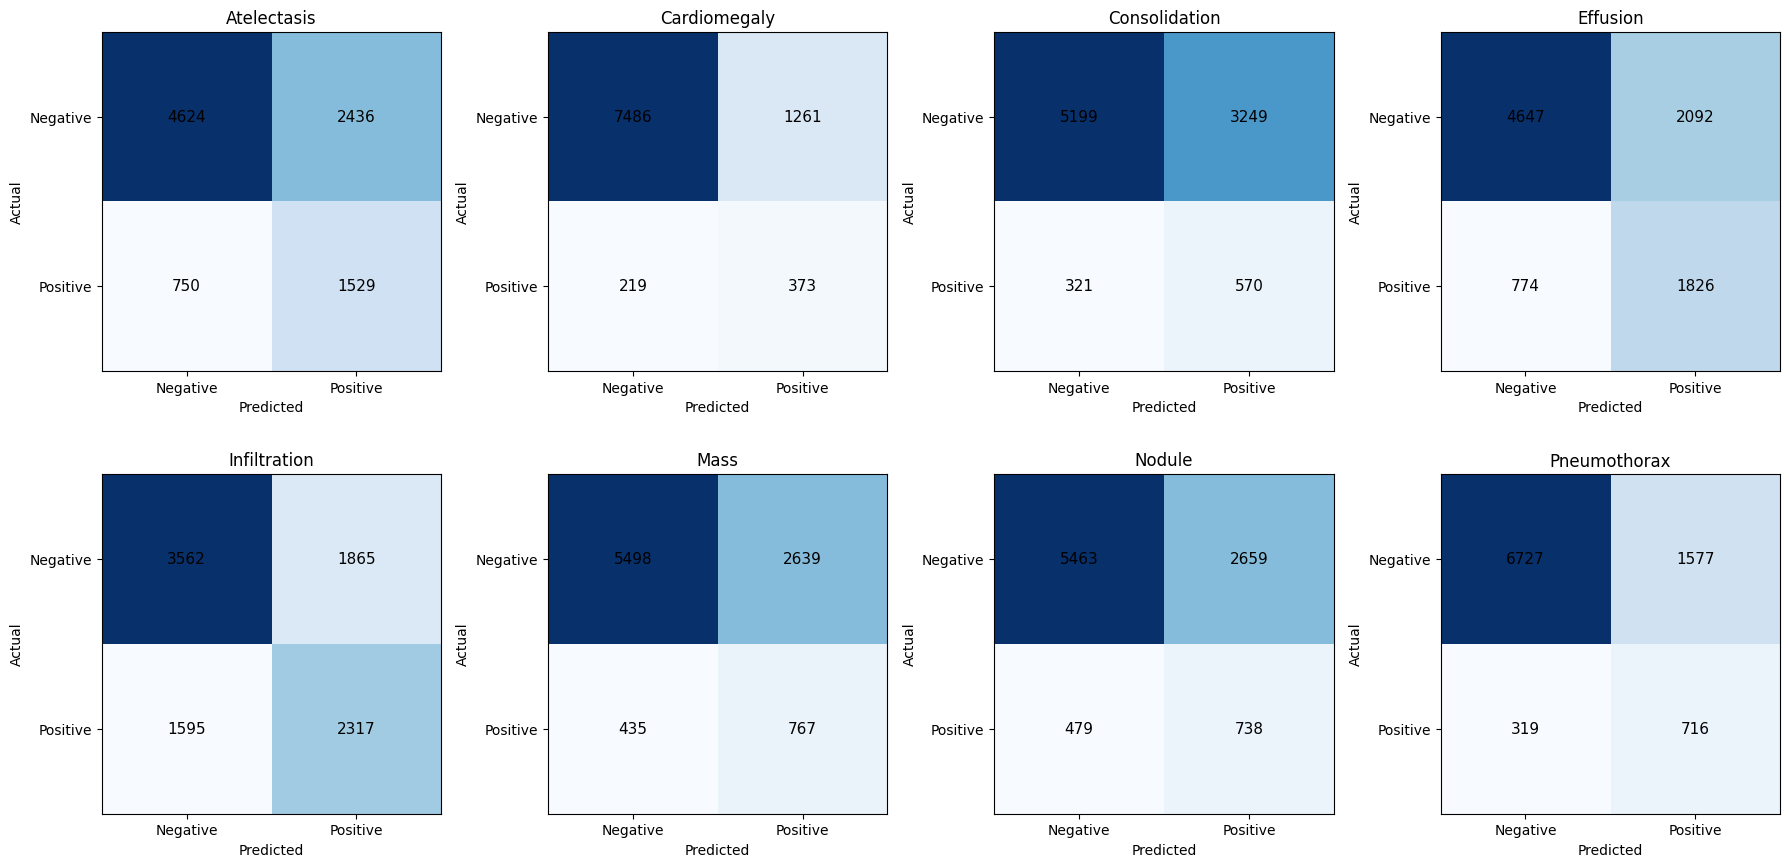

In [ ]:
# ============================================================
# MULTI-LABEL CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

axes = axes.flatten()

for i, disease in enumerate(TARGET_DISEASES):

    cm = confusion_matrix(
        all_labels[:, i],
        predictions[:, i]
    )

    ax = axes[i]

    im = ax.imshow(cm, cmap="Blues")

    ax.set_title(disease, fontsize=12)

    ax.set_xlabel("Predicted")

    ax.set_ylabel("Actual")

    ax.set_xticks([0,1])
    ax.set_xticklabels(["Negative","Positive"])

    ax.set_yticks([0,1])
    ax.set_yticklabels(["Negative","Positive"])

    for r in range(2):
        for c in range(2):
            ax.text(
                c,
                r,
                str(cm[r,c]),
                ha="center",
                va="center",
                fontsize=11,
                color="black"
            )

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

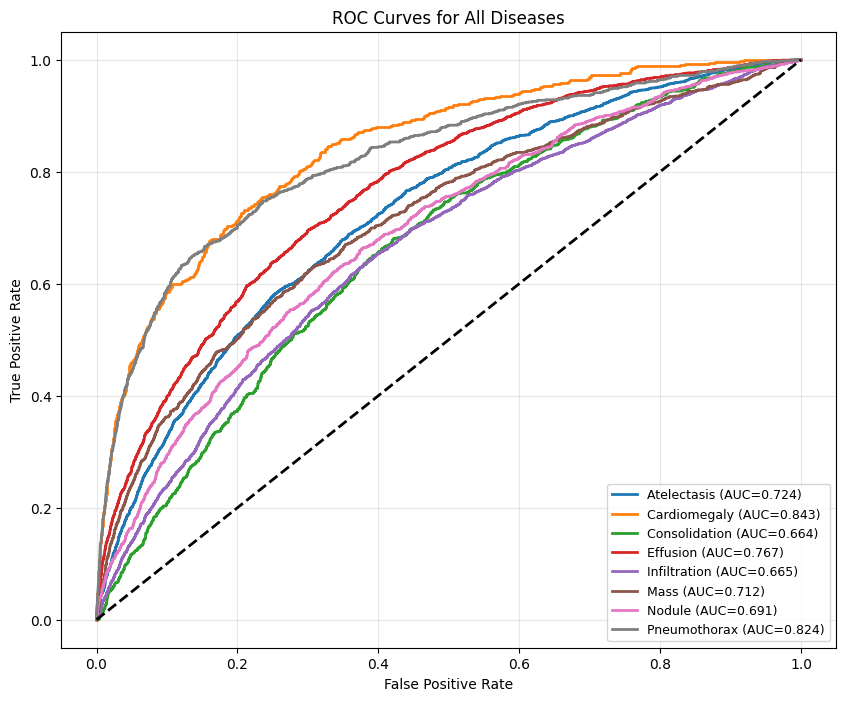

In [ ]:
# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(10,8))

for i, disease in enumerate(TARGET_DISEASES):

    fpr, tpr, _ = roc_curve(
        all_labels[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{disease} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],"k--",lw=2)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves for All Diseases")

plt.legend(fontsize=9)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

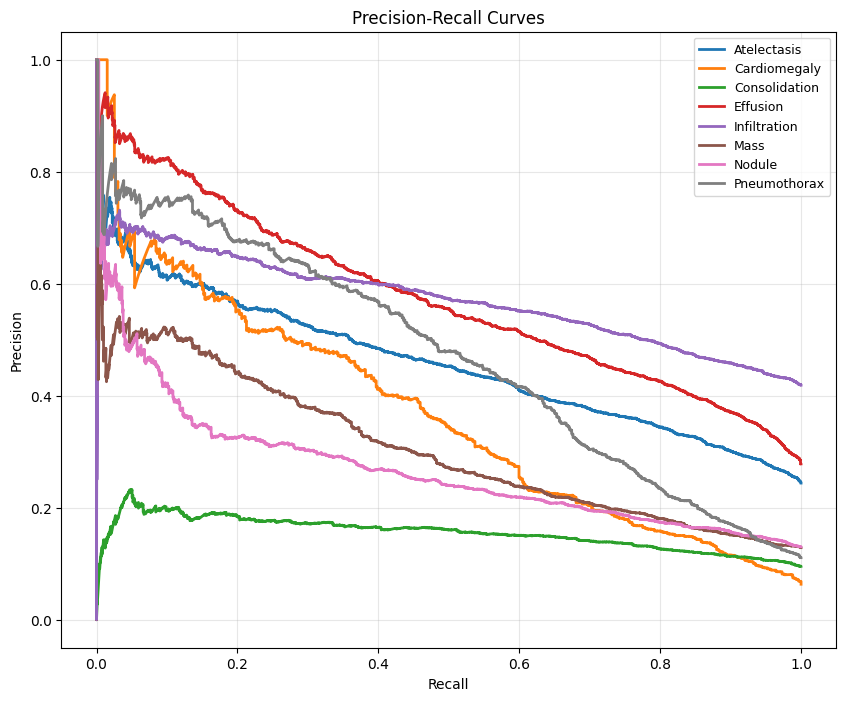

In [ ]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================

plt.figure(figsize=(10,8))

for i, disease in enumerate(TARGET_DISEASES):

    precision, recall, _ = precision_recall_curve(
        all_labels[:, i],
        all_probs[:, i]
    )

    plt.plot(
        recall,
        precision,
        lw=2,
        label=disease
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curves")

plt.legend(fontsize=9)

plt.grid(alpha=0.3)

plt.show()

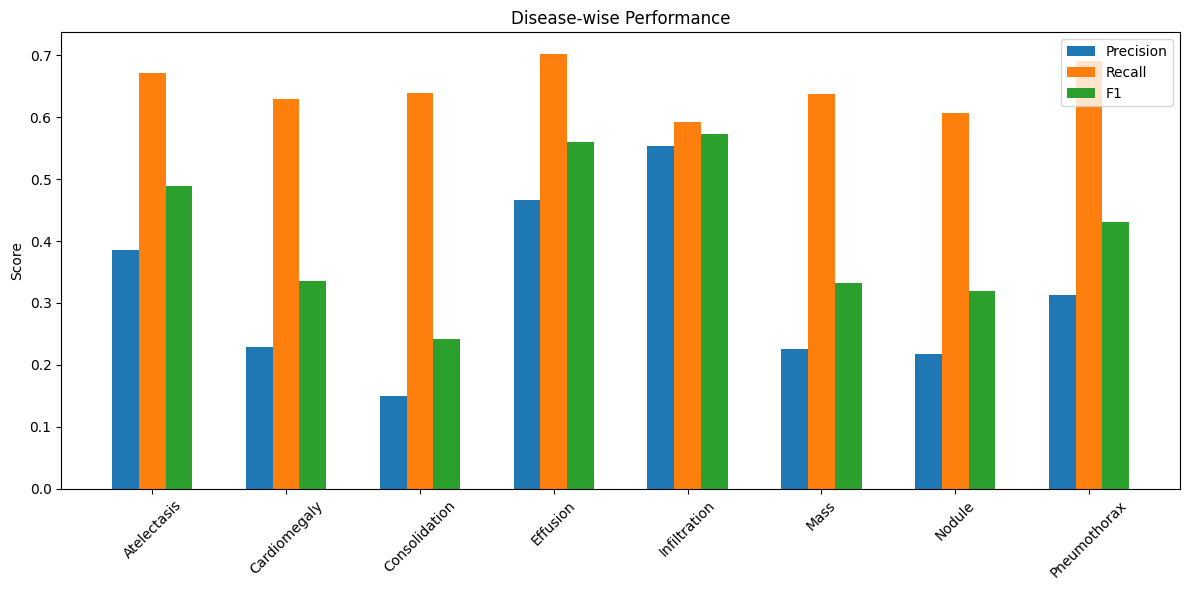

In [ ]:
plt.figure(figsize=(12,6))

x = np.arange(len(TARGET_DISEASES))

width = 0.2

plt.bar(
    x-width,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    results_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x+width,
    results_df["F1"],
    width,
    label="F1"
)

plt.xticks(
    x,
    TARGET_DISEASES,
    rotation=45
)

plt.ylabel("Score")

plt.title("Disease-wise Performance")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np

from sklearn.metrics import f1_score

best_thresholds = []

print("="*70)
print("Finding Best Threshold for Each Disease")
print("="*70)

for i, disease in enumerate(TARGET_DISEASES):

    best_f1 = 0
    best_threshold = 0.5

    for threshold in np.arange(0.10, 0.91, 0.02):

        preds = (all_probs[:, i] >= threshold).astype(int)

        f1 = f1_score(all_labels[:, i], preds)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    best_thresholds.append(best_threshold)

    print(f"{disease:20s}  Threshold = {best_threshold:.2f}   Best F1 = {best_f1:.4f}")

best_thresholds = np.array(best_thresholds)

Finding Best Threshold for Each Disease
Atelectasis           Threshold = 0.56   Best F1 = 0.4910
Cardiomegaly          Threshold = 0.80   Best F1 = 0.4173
Consolidation         Threshold = 0.58   Best F1 = 0.2439
Effusion              Threshold = 0.50   Best F1 = 0.5603
Infiltration          Threshold = 0.40   Best F1 = 0.6103
Mass                  Threshold = 0.62   Best F1 = 0.3607
Nodule                Threshold = 0.54   Best F1 = 0.3265
Pneumothorax          Threshold = 0.68   Best F1 = 0.4934


In [ ]:
optimized_predictions = np.zeros_like(all_probs)

for i in range(len(TARGET_DISEASES)):

    optimized_predictions[:, i] = (
        all_probs[:, i] >= best_thresholds[i]
    ).astype(int)

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    hamming_loss
)

# Hamming Accuracy (Recommended for Multi-label Classification)
hamming_accuracy = 1 - hamming_loss(
    all_labels,
    optimized_predictions
)

# Other Metrics
precision = precision_score(
    all_labels,
    optimized_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_labels,
    optimized_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    optimized_predictions,
    average="macro",
    zero_division=0
)

auc = roc_auc_score(
    all_labels,
    all_probs,
    average="macro"
)

print("="*50)
print("Optimized Evaluation")
print("="*50)

print(f"Hamming Accuracy : {hamming_accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"ROC AUC          : {auc:.4f}")

Optimized Evaluation
Hamming Accuracy : 0.7467
Precision        : 0.3641
Recall           : 0.5726
F1 Score         : 0.4379
ROC AUC          : 0.7363


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    optimized_predictions,
    average=None,
    zero_division=0
)

auc_scores = []

for i in range(len(TARGET_DISEASES)):
    auc_scores.append(
        roc_auc_score(
            all_labels[:, i],
            all_probs[:, i]
        )
    )

import pandas as pd

optimized_results = pd.DataFrame({

    "Disease": TARGET_DISEASES,

    "Threshold": best_thresholds,

    "Precision": precision,

    "Recall": recall,

    "F1": f1,

    "ROC_AUC": auc_scores

})

optimized_results

,Disease,Threshold,Precision,Recall,F1,ROC_AUC
0,Atelectasis,0.56,0.426995,0.577446,0.490953,0.724481
1,Cardiomegaly,0.80,0.396055,0.440878,0.417266,0.842615
2,Consolidation,0.58,0.163304,0.481481,0.243889,0.663737
3,Effusion,0.50,0.466054,0.702308,0.560295,0.767476
4,Infiltration,0.40,0.497662,0.788855,0.610304,0.664531
5,Mass,0.62,0.289527,0.478369,0.360728,0.712272
6,Nodule,0.54,0.231670,0.552999,0.326541,0.691072
7,Pneumothorax,0.68,0.441896,0.558454,0.493385,0.824144


In [ ]:
torch.save(model.state_dict(), "DenseNet121_8Disease_Final.pth")

In [ ]:
import numpy as np

np.save("best_thresholds.npy", best_thresholds)

In [ ]:
optimized_results.to_csv(
    "Disease_Wise_Results.csv",
    index=False
)

optimized_results

,Disease,Threshold,Precision,Recall,F1,ROC_AUC
0,Atelectasis,0.56,0.426995,0.577446,0.490953,0.724481
1,Cardiomegaly,0.80,0.396055,0.440878,0.417266,0.842615
2,Consolidation,0.58,0.163304,0.481481,0.243889,0.663737
3,Effusion,0.50,0.466054,0.702308,0.560295,0.767476
4,Infiltration,0.40,0.497662,0.788855,0.610304,0.664531
5,Mass,0.62,0.289527,0.478369,0.360728,0.712272
6,Nodule,0.54,0.231670,0.552999,0.326541,0.691072
7,Pneumothorax,0.68,0.441896,0.558454,0.493385,0.824144


In [ ]:
import timm

print(type(model))

<class 'timm.models.densenet.DenseNet'>


In [ ]:
print(model.features)

Sequential(
  (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (norm0): BatchNormAct2d(
    64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (denseblock1): DenseBlock(
    (denselayer1): DenseLayer(
      (norm1): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNormAct2d(
        128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): DenseLayer(
      (norm1): BatchNormAct2d(
        

In [ ]:
import os

print(os.listdir("/kaggle/working"))

['Disease_Wise_Results.csv', 'DenseNet121_8Disease_Final.pth', '.virtual_documents', 'roc_curve.png', 'disease_wise_results.csv', 'confusion_matrix.png', 'best_thresholds.npy', 'best_model.pth']


In [ ]:
torch.save(model.state_dict(), "DenseNet121_8Disease_Final.pth")

In [ ]:
import numpy as np

np.save("best_thresholds.npy", best_thresholds)

In [ ]:
optimized_results.to_csv(
    "Disease_Wise_Results.csv",
    index=False
)

In [ ]:
import os

for file in os.listdir("/kaggle/working"):
    print(file)

Disease_Wise_Results.csv
DenseNet121_8Disease_Final.pth
.virtual_documents
roc_curve.png
disease_wise_results.csv
confusion_matrix.png
best_thresholds.npy
best_model.pth


In [ ]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 20.7 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
print(device)

print(type(model))

print(TARGET_DISEASES)

print(test_df.head())

NameError: name 'device' is not defined